# T4 — test transferu osi Strykera na własne zdjęcia

## Pytanie

Czy oś "ludzkiej historii" znaleziona na FSA (lata 30., B&W, USA) przenosi się na zdjęcia z **innej dekady, miejsca i techniki** (Twoje — kolor, cyfra, XXI w.)? Jeśli tak — oś koduje znaczenie i kompozycję, nie powierzchnię epoki.

## Dwa tryby

- **TRYB A (z etykietami — mocny dowód)**: podziel zdjęcia PRZED uruchomieniem na foldery `wybrane/` i `odrzucone/` wg własnej dawnej selekcji. Liczymy d' i porównujemy z benchmarkiem FSA (0.188, parowo 59%).
- **TRYB B (bez etykiet)**: jeden folder → ranking wg osi, oceniasz okiem.

## Kontrole wbudowane

1. **Baseline permutacyjny** na Twoich danych (ile daje szum)
2. **Kontrola B&W**: rzuty na kolorze vs po konwersji do szarości — stabilny ranking = oś nie czyta koloru (test T3 na współczesnych danych)

## Uwaga interpretacyjna

Porównujemy RANKING wewnątrz Twojego zbioru, nie surowe wartości z FSA (domain shift przesuwa stałą). Formaty: JPG/PNG (HEIC przekonwertuj wcześniej). Minimum ~20 zdjęć na folder dla sensownej statystyki.


## 0. Setup

In [10]:
from google.colab import drive
drive.mount('/content/drive')
!pip install -q open_clip_torch scipy 2>/dev/null


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
import torch, open_clip
from scipy.stats import spearmanr
np.set_printoptions(precision=4, suppress=True)

DRIVE = Path('/content/drive/MyDrive/fsa_data')

# ===== KONFIGURACJA — ustaw ścieżkę do swoich zdjęć =====
MY_PHOTOS = Path('/content/drive/MyDrive/moje_zdjecia')   # <- tu wgraj zdjęcia (panel plików)
# TRYB A: MY_PHOTOS/wybrane/*.jpg + MY_PHOTOS/odrzucone/*.jpg
# TRYB B: zdjęcia bezpośrednio w MY_PHOTOS/*.jpg
MY_PHOTOS.mkdir(exist_ok=True)

# Osie z badania FSA
with np.load(DRIVE/'akt1_axes.npz') as d:
    v_hole, v_sharp = d['v_hole'], d['v_sharp']
with np.load(DRIVE/'akt2b_axes.npz') as d:
    v_clean3 = d['v_clean3']; v_bright = d['v_bright']; v_contrast = d['v_contrast']
V = np.stack([v_hole, v_sharp, v_bright, v_contrast], axis=1)
Q, _ = np.linalg.qr(V)
def neutralize(e):
    e = np.atleast_2d(e)
    return e - (e @ Q) @ Q.T

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model, _, preprocess = open_clip.create_model_and_transforms('ViT-B-32', pretrained='laion2b_s34b_b79k')
model = model.to(device).eval()
print(f'✅ Oś v_clean3 + neutralizator 4D wczytane; CLIP na {device}')
print(f'Wgraj zdjęcia do: {MY_PHOTOS} (tryb A: podfoldery wybrane/ i odrzucone/)')


✅ Oś v_clean3 + neutralizator 4D wczytane; CLIP na cuda
Wgraj zdjęcia do: /content/drive/MyDrive/moje_zdjecia (tryb A: podfoldery wybrane/ i odrzucone/)


## 1. Wczytaj zdjęcia — automatyczne wykrycie trybu

In [14]:
EXTS = ('.jpg','.jpeg','.png','.webp')
def list_imgs(p):
    return sorted([f for f in p.iterdir() if f.suffix.lower() in EXTS]) if p.exists() else []

dir_w, dir_o = MY_PHOTOS/'wybrane', MY_PHOTOS/'odrzucone'
files_w, files_o = list_imgs(dir_w), list_imgs(dir_o)

if files_w and files_o:
    MODE = 'A'
    files = files_w + files_o
    labels = np.array([1]*len(files_w) + [0]*len(files_o))
    print(f'TRYB A (z etykietami): wybrane={len(files_w)}, odrzucone={len(files_o)}')
    if min(len(files_w), len(files_o)) < 20:
        print('⚠ <20 zdjęć w którymś folderze — statystyka będzie zgrubna')
else:
    MODE = 'B'
    files = list_imgs(MY_PHOTOS)
    labels = None
    print(f'TRYB B (bez etykiet): {len(files)} zdjęć — będzie ranking do oceny okiem')
assert len(files) > 0, 'Brak zdjęć! Wgraj pliki i uruchom ponownie.'


TRYB B (bez etykiet): 364 zdjęć — będzie ranking do oceny okiem


## 2. Embeddingi CLIP — kolor + kontrola B&W

In [15]:
@torch.no_grad()
def embed(pil):
    x = preprocess(pil).unsqueeze(0).to(device)
    e = model.encode_image(x)
    e = e/e.norm(dim=-1, keepdim=True)
    return e[0].float().cpu().numpy().astype(np.float64)

from tqdm.auto import tqdm
E_col, E_bw = [], []
for f in tqdm(files, desc='CLIP'):
    pil = ImageOps.exif_transpose(Image.open(f)).convert('RGB')
    E_col.append(embed(pil))
    E_bw.append(embed(ImageOps.grayscale(pil).convert('RGB')))
E_col, E_bw = np.array(E_col), np.array(E_bw)

# Rzuty na oś (z neutralizacją, jak w Akcie 2b)
p_col = neutralize(E_col) @ v_clean3
p_bw  = neutralize(E_bw)  @ v_clean3
print(f'Rzuty policzone: {len(files)} zdjęć (kolor + B&W)')


CLIP:   0%|          | 0/364 [00:00<?, ?it/s]

Rzuty policzone: 364 zdjęć (kolor + B&W)


## 3. Ranking wg osi Strykera — góra i dół Twojego zbioru

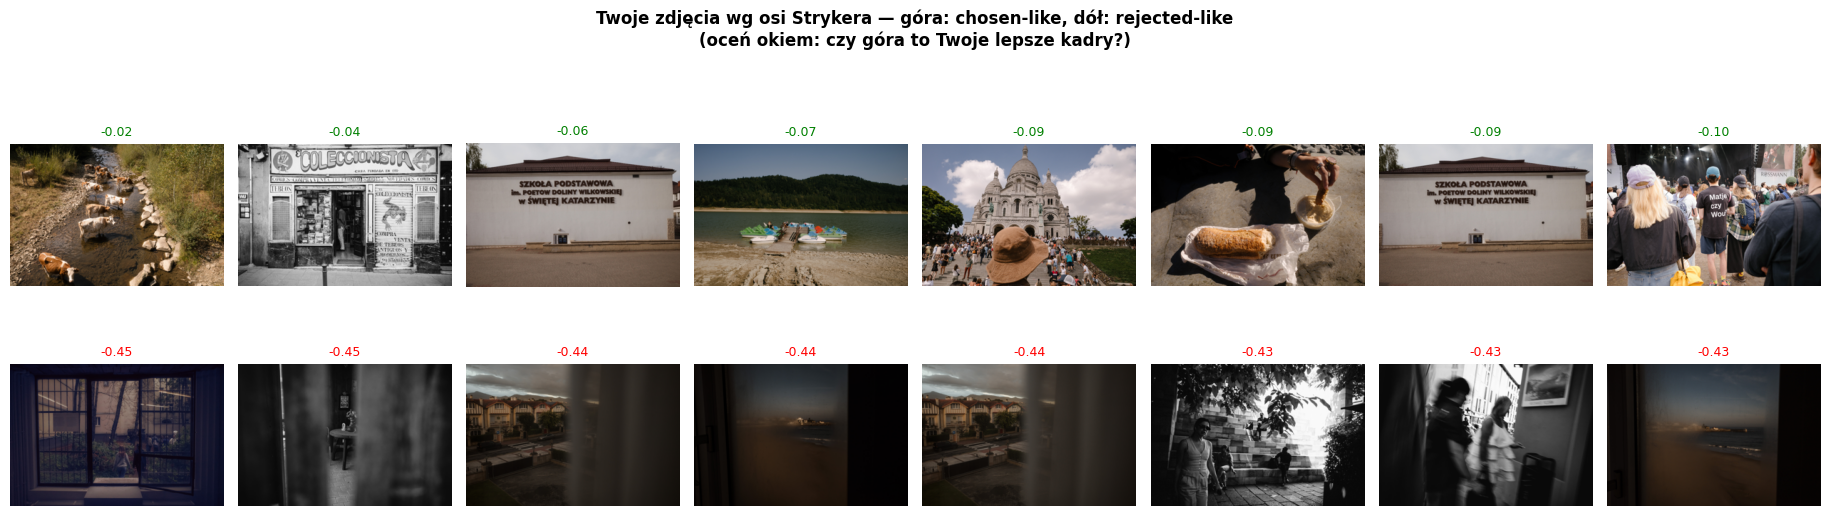

In [16]:
order = np.argsort(p_col)
N = min(8, len(files)//2)
fig, axes = plt.subplots(2, N, figsize=(2.3*N, 6))
for j in range(N):
    hi = order[-1-j]; lo = order[j]
    for row, idx in [(0, hi), (1, lo)]:
        pil = ImageOps.exif_transpose(Image.open(files[idx])).convert('RGB')
        pil.thumbnail((300,300))
        axes[row,j].imshow(pil); axes[row,j].axis('off')
        lab = ''
        if MODE=='A': lab = ' [W]' if labels[idx]==1 else ' [O]'
        axes[row,j].set_title(f'{p_col[idx]:+.2f}{lab}', fontsize=9,
                              color='green' if row==0 else 'red')
axes[0,0].set_ylabel('TOP osi'); axes[1,0].set_ylabel('DÓŁ osi')
plt.suptitle('Twoje zdjęcia wg osi Strykera — góra: chosen-like, dół: rejected-like\n' +
             ('([W]=Twoje wybrane, [O]=odrzucone — zgodność z osią?)' if MODE=='A' else '(oceń okiem: czy góra to Twoje lepsze kadry?)'),
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()


## 4. TRYB A — pomiar d' na Twoich etykietach (rdzeń testu T4)

In [6]:
if MODE == 'A':
    a, b = p_col[labels==1], p_col[labels==0]
    dprime = abs(a.mean()-b.mean())/(np.sqrt(0.5*(a.var()+b.var()))+1e-12)
    sign_ok = a.mean() > b.mean()   # wybrane powinny być WYŻEJ na osi
    # AUC empirycznie (Mann-Whitney) — bez założeń o kształcie
    auc = float(np.mean(a[:,None] > b[None,:]) + 0.5*np.mean(a[:,None] == b[None,:]))
    # Baseline permutacyjny na TWOICH danych
    rng = np.random.RandomState(0); d_perm = []
    for _ in range(500):
        sh = rng.permutation(labels)
        ap, bp = p_col[sh==1], p_col[sh==0]
        d_perm.append(abs(ap.mean()-bp.mean())/(np.sqrt(0.5*(ap.var()+bp.var()))+1e-12))
    d_noise95 = float(np.percentile(d_perm, 95))

    print('='*58)
    print('TEST TRANSFERU T4 — Twoje zdjęcia, oś z FSA')
    print('='*58)
    print(f"d' na Twoich etykietach:      {dprime:.3f}   (kierunek {'OK — wybrane wyżej' if sign_ok else 'ODWROTNY!'})")
    print(f'AUC (P(wybrane > odrzucone)): {auc:.3f}   (0.5 = losowo)')
    print(f'próg szumu 95% (permutacje):  {d_noise95:.3f}')
    print(f'benchmark FSA (dla skali):    d\'=0.188, parowo 59%')
    print()
    if sign_ok and dprime > d_noise95:
        print('→ TRANSFER POTWIERDZONY: oś z lat 30. rozdziela Twoje współczesne wybory')
        print('  ponad szum. Oś koduje znaczenie/kompozycję, nie powierzchnię epoki (T4 ✅).')
    elif sign_ok:
        print('→ Kierunek zgodny, ale poniżej progu szumu — transfer słaby/niekonkludywny.')
        print('  Możliwe przyczyny: mało zdjęć, selekcja z powodów technicznych, inny gatunek.')
    else:
        print('→ Kierunek ODWROTNY — oś nie transferuje (lub Twoje kryteria selekcji są inne')
        print('  niż "ludzka historia" — co samo w sobie jest ciekawym wynikiem!).')
else:
    print('TRYB B: pomiar d\' wymaga etykiet. Oceń ranking z sekcji 3 okiem —')
    print('albo podziel zdjęcia na wybrane/odrzucone i uruchom ponownie.')


TEST TRANSFERU T4 — Twoje zdjęcia, oś z FSA
d' na Twoich etykietach:      0.110   (kierunek ODWROTNY!)
AUC (P(wybrane > odrzucone)): 0.452   (0.5 = losowo)
próg szumu 95% (permutacje):  0.542
benchmark FSA (dla skali):    d'=0.188, parowo 59%

→ Kierunek ODWROTNY — oś nie transferuje (lub Twoje kryteria selekcji są inne
  niż "ludzka historia" — co samo w sobie jest ciekawym wynikiem!).


## 5. Kontrola B&W — czy oś czyta kolor? (test powierzchni T3)

Spearman ρ rankingu (kolor vs B&W): 0.880
  ρ > 0.9  → ranking stabilny: oś NIE czyta koloru/powierzchni (T3 ✅ na Twoich danych)
  ρ < 0.7  → konwersja zmienia ranking: część rzutu zależy od palety (uwaga)


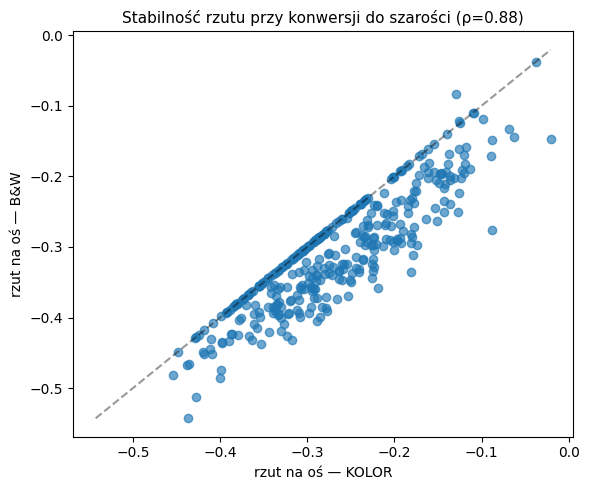

In [17]:
rho, _ = spearmanr(p_col, p_bw)
print(f'Spearman ρ rankingu (kolor vs B&W): {rho:.3f}')
print('  ρ > 0.9  → ranking stabilny: oś NIE czyta koloru/powierzchni (T3 ✅ na Twoich danych)')
print('  ρ < 0.7  → konwersja zmienia ranking: część rzutu zależy od palety (uwaga)')

fig, ax = plt.subplots(figsize=(6,5))
if MODE=='A':
    for lab, col, nm in [(1,'green','wybrane'),(0,'red','odrzucone')]:
        m = labels==lab
        ax.scatter(p_col[m], p_bw[m], c=col, alpha=0.65, label=nm)
    ax.legend()
else:
    ax.scatter(p_col, p_bw, alpha=0.65)
lims = [min(p_col.min(),p_bw.min()), max(p_col.max(),p_bw.max())]
ax.plot(lims, lims, 'k--', alpha=0.4)
ax.set_xlabel('rzut na oś — KOLOR'); ax.set_ylabel('rzut na oś — B&W')
ax.set_title(f'Stabilność rzutu przy konwersji do szarości (ρ={rho:.2f})', fontsize=11)
plt.tight_layout(); plt.show()


## 6. Największe niezgodności — gdzie oś i Ty się różnicie (tylko tryb A)

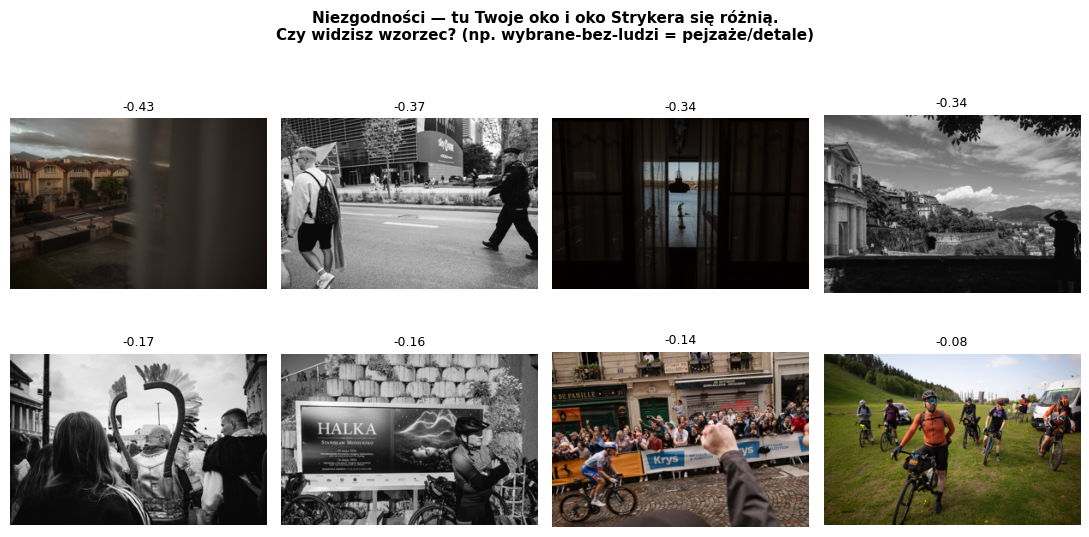

Niezgodności są informacją: pokazują, CZYM Twoje kryterium różni się od osi
"ludzkiej historii" — nie błędem któregokolwiek z was.


In [8]:
if MODE == 'A':
    # Wybrane, które oś oceniła najniżej + odrzucone, które oceniła najwyżej
    w_idx = np.where(labels==1)[0]; o_idx = np.where(labels==0)[0]
    w_low = w_idx[np.argsort(p_col[w_idx])][:4]     # Twoje wybrane, oś: słabe
    o_high = o_idx[np.argsort(p_col[o_idx])][-4:]   # Twoje odrzucone, oś: dobre
    fig, axes = plt.subplots(2, 4, figsize=(11, 6))
    for j, idx in enumerate(w_low):
        pil = ImageOps.exif_transpose(Image.open(files[idx])).convert('RGB'); pil.thumbnail((300,300))
        axes[0,j].imshow(pil); axes[0,j].axis('off')
        axes[0,j].set_title(f'{p_col[idx]:+.2f}', fontsize=9)
    for j, idx in enumerate(o_high):
        pil = ImageOps.exif_transpose(Image.open(files[idx])).convert('RGB'); pil.thumbnail((300,300))
        axes[1,j].imshow(pil); axes[1,j].axis('off')
        axes[1,j].set_title(f'{p_col[idx]:+.2f}', fontsize=9)
    axes[0,0].set_ylabel('Twoje WYBRANE\noś: nisko')
    axes[1,0].set_ylabel('Twoje ODRZUCONE\noś: wysoko')
    plt.suptitle('Niezgodności — tu Twoje oko i oko Strykera się różnią.\nCzy widzisz wzorzec? (np. wybrane-bez-ludzi = pejzaże/detale)', fontsize=11, fontweight='bold')
    plt.tight_layout(); plt.show()
    print('Niezgodności są informacją: pokazują, CZYM Twoje kryterium różni się od osi')
    print('"ludzkiej historii" — nie błędem któregokolwiek z was.')
else:
    print('(sekcja wymaga trybu A)')


## 7. Zapis wyników

In [9]:
out = {'mode': MODE, 'n_photos': len(files), 'spearman_color_bw': float(rho),
       'projections_color': p_col.tolist(), 'files': [f.name for f in files]}
if MODE=='A':
    out.update({'dprime': float(dprime), 'auc': float(auc), 'sign_ok': bool(sign_ok),
                'noise95': d_noise95, 'labels': labels.tolist()})
with open(DRIVE/'t4_transfer_results.json','w') as f:
    json.dump(out, f, indent=2)
print('✅ Zapisano t4_transfer_results.json na Drive')


✅ Zapisano t4_transfer_results.json na Drive
